## historical wheather data during FEBRUARY/MARCH

In [80]:
%matplotlib widget
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Specifica il percorso del file
file_path = "/Users/filippomichelon/Desktop/open-meteo-47.98S72.06W1115m.csv"


# Carica il CSV in un DataFrame
df = pd.read_csv(file_path, sep=";")


df = df.dropna(subset=['temp', 'time'])  # Skip rows with missing temperature or time
df['temp_smooth'] = df['temp'].rolling(window=100000, center=True).mean()
df['wind_smooth'] = df['wind'].rolling(window=100000, center=True).mean()

# Visualizza le prime righe del DataFrame
print(df.head())

               time  temp  wind  temp_smooth  wind_smooth
0  1941-01-01T00:00  -3.7  10.2          NaN          NaN
1  1941-01-01T01:00  -4.1  10.5          NaN          NaN
2  1941-01-01T02:00  -5.0  10.4          NaN          NaN
3  1941-01-01T03:00  -5.3  10.3          NaN          NaN
4  1941-01-01T04:00  -5.1  11.0          NaN          NaN


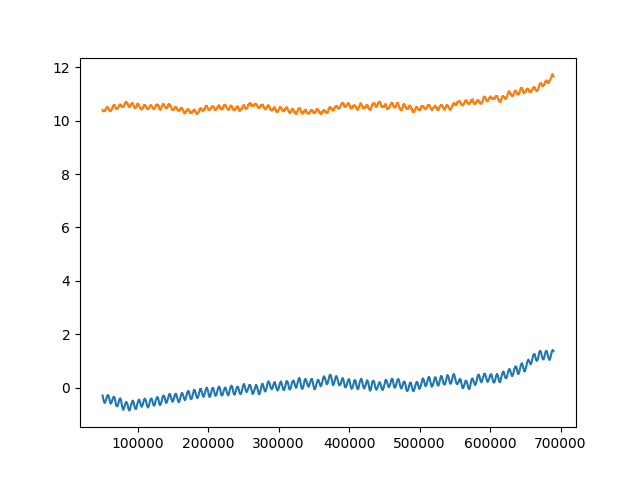

In [81]:
plt.figure()
#plt.plot(df.temp)
plt.plot(df.temp_smooth)
plt.plot(df.wind_smooth)

#plt.xlim([0, 10000])

In [66]:
df.index

RangeIndex(start=0, stop=739992, step=1)

In [82]:
df['year'] = df['time'].dt.year

# Group by year and calculate mean temp and wind
yearly_means = df.groupby('year')[['temp', 'wind']].mean().reset_index()

print(yearly_means.head())

AttributeError: Can only use .dt accessor with datetimelike values

In [83]:
df['time'] = pd.to_datetime(df['time'], errors='coerce')

In [84]:
df

,time,temp,wind,temp_smooth,wind_smooth
0,1941-01-01 00:00:00,-3.7,10.2,NaN,NaN
1,1941-01-01 01:00:00,-4.1,10.5,NaN,NaN
2,1941-01-01 02:00:00,-5.0,10.4,NaN,NaN
3,1941-01-01 03:00:00,-5.3,10.3,NaN,NaN
4,1941-01-01 04:00:00,-5.1,11.0,NaN,NaN
...,...,...,...,...,...
739987,2025-06-01 19:00:00,-1.3,14.3,NaN,NaN
739988,2025-06-01 20:00:00,-1.5,16.4,NaN,NaN
739989,2025-06-01 21:00:00,-1.7,19.0,NaN,NaN
739990,2025-06-01 22:00:00,-1.9,18.4,NaN,NaN


In [85]:
print(df['time'].head())
print(df['time'].dtype)  # Should say datetime64[ns]

0   1941-01-01 00:00:00
1   1941-01-01 01:00:00
2   1941-01-01 02:00:00
3   1941-01-01 03:00:00
4   1941-01-01 04:00:00
Name: time, dtype: datetime64[ns]
datetime64[ns]


In [91]:
df['year'] = df['time'].dt.year
yearly_means = df.groupby('year')[['temp', 'wind']].mean().reset_index()
print(yearly_means.head())
df['year'] = df['time'].dt.year
yearly_var = df.groupby('year')[['temp', 'wind']].std().reset_index()
print(yearly_var.head())

   year      temp       wind
0  1941  0.215537   9.942386
1  1942  0.086610   9.875000
2  1943 -0.110263  10.292500
3  1944  0.583242   9.755168
4  1945 -0.407877  10.341963
   year      temp      wind
0  1941  5.217577  5.438900
1  1942  5.843376  5.511874
2  1943  5.564545  5.412240
3  1944  6.416011  5.045454
4  1945  5.573866  5.295958


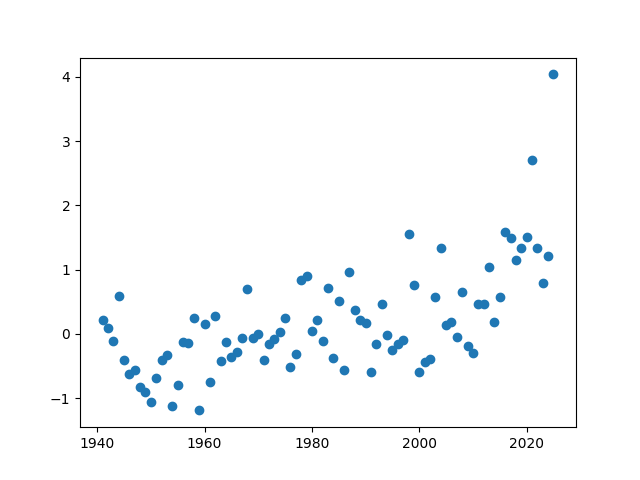

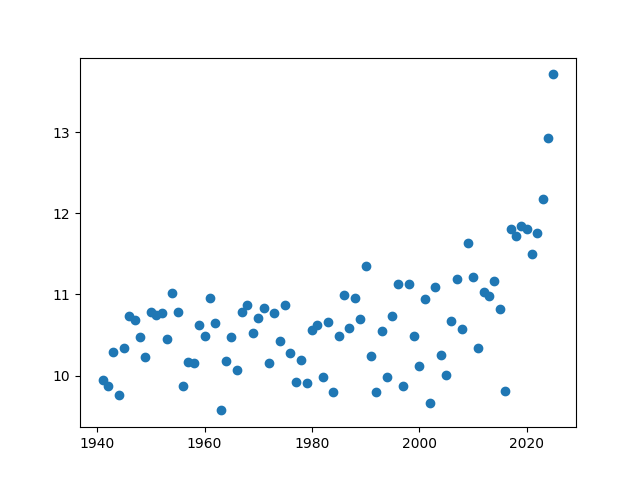

In [89]:
plt.figure()
plt.scatter(yearly_means.year,yearly_means.temp)
plt.figure()
plt.scatter(yearly_means.year,yearly_means.wind)

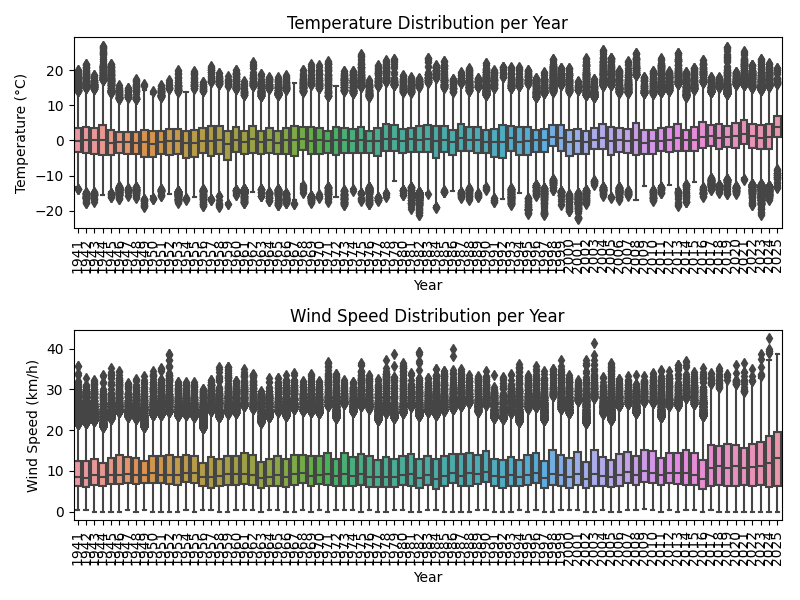

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns  # nicer plots for categories

plt.figure(figsize=(8,6))

# Boxplot for temperature by year
plt.subplot(2, 1, 1)
sns.boxplot(x='year', y='temp', data=df)
plt.xticks(rotation=90)
plt.title('Temperature Distribution per Year')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')

# Boxplot for wind speed by year
plt.subplot(2, 1, 2)
sns.boxplot(x='year', y='wind', data=df)
plt.xticks(rotation=90)
plt.title('Wind Speed Distribution per Year')
plt.xlabel('Year')
plt.ylabel('Wind Speed (km/h)')

plt.tight_layout()
plt.show()


In [ ]:
sns.boxplot(df.year, y='wind', data=df)

(array([0.00105086, 0.00297744, 0.00394073, 0.00709332, 0.00770632,
        0.01094648, 0.01331091, 0.01742679, 0.02758512, 0.03721802,
        0.04685092, 0.05884826, 0.08538251, 0.07767619, 0.07618747,
        0.06506585, 0.0568341 , 0.04142147, 0.02872355, 0.02662183,
        0.0226811 , 0.01506235, 0.0130482 , 0.00875718, 0.0062176 ,
        0.00359044, 0.00227687, 0.00236444, 0.00166386, 0.00070057]),
 array([-17. , -15.7, -14.4, -13.1, -11.8, -10.5,  -9.2,  -7.9,  -6.6,
         -5.3,  -4. ,  -2.7,  -1.4,  -0.1,   1.2,   2.5,   3.8,   5.1,
          6.4,   7.7,   9. ,  10.3,  11.6,  12.9,  14.2,  15.5,  16.8,
         18.1,  19.4,  20.7,  22. ]),
 <BarContainer object of 30 artists>)

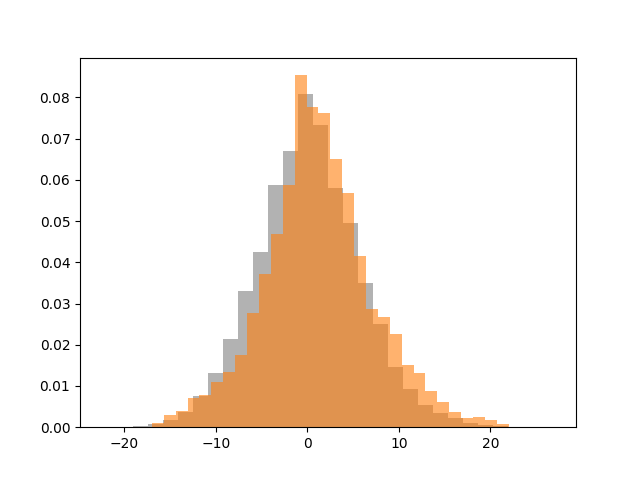

In [110]:
plt.figure()
plt.hist(df.temp, bins=30, density=True, alpha=.6, facecolor= 'grey')

plt.hist(df.temp[df.year == 2024], bins=30, density=True, alpha=0.6)
#plt.hist(df.temp[df.year == 1950], bins=30, density=True, alpha=0.6)